# Model đúng ở đâu, sai ở đâu — mổ theo giá, thời tiết và giờ

> Notebook này trả lời bốn câu hỏi cụ thể:
>
> 1. Hiện tại model **dự đoán đúng ở đâu, sai ở đâu**?
> 2. Ở các **khoảng giá** khác nhau thì sai số thế nào?
> 3. Ở các **điều kiện thời tiết** khác nhau thì sai số bao nhiêu?
> 4. Ở các **khung giờ** khác nhau thì model dự đoán ra sao?

Khác với `09_chan_doan_model` (xếp hạng *chiều nào* quan trọng bằng η²), notebook này đi
sâu vào **ba chiều mentor quan tâm nhất**, và mỗi chiều đều kèm **sai số lấy mẫu** để phân
biệt chênh lệch thật với nhiễu — vì có nhóm chỉ vài trăm chuyến, chênh 3 điểm % vẫn có thể
là ngẫu nhiên.

## Bộ chỉ số dùng xuyên suốt

| Chỉ số | Ý nghĩa | Vì sao cần |
|---|---|---|
| **MAPE** | sai số tương đối trung bình | chỉ số chính, nhưng bị đuôi kéo |
| **MdAPE** | trung vị sai số tương đối | chuyến điển hình sai bao nhiêu |
| **% trong ±10%** | tỷ lệ chuyến "dùng được" | ngôn ngữ của người vận hành |
| **% ngoài ±20%** | tỷ lệ chuyến "hỏng" | rủi ro khi demo |
| **Bias** | (dự đoán − thật)/thật trung bình | đoán cao hay thấp một cách hệ thống |
| **Hơn persistence** | giảm bao nhiêu % MAE so với lấy thẳng giá quan sát gần nhất | model có học được gì không |

Mốc so sánh **persistence** quan trọng: một nhóm có MAPE cao chưa chắc là chỗ model kém —
có thể nhóm đó vốn khó, và model vẫn hơn hẳn cách làm ngây thơ.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 13, "axes.labelsize": 11.5,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5, "legend.fontsize": 10.5,
})
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

# ── dữ liệu: dự đoán trên test độc lập ────────────────────────────────────
u = pd.read_parquet("uq_pred_test.parquet")
raw = pd.read_parquet("../../data/hcm_train_ready.parquet", columns=[
    "split", "evaluation_month", "target_timestamp",
    "service_name", "target_is_weekend"])
raw = (raw[raw.split == "test"].sort_values("evaluation_month", kind="stable")
       .reset_index(drop=True))
u = u.sort_values("evaluation_month", kind="stable").reset_index(drop=True)
assert np.allclose(raw.target_timestamp.values.astype("int64"),
                   u.target_timestamp.values.astype("int64")), "lệch hàng"
t = pd.concat([u, raw[["service_name", "target_is_weekend"]]], axis=1)

# Mỗi chuyến xuất hiện 4 lần (4 mức trễ yêu cầu) — giữ 1 để không đếm trùng
t = t[t.requested_lag_minutes == 5].copy()

t["ae"]   = (t.hybrid_pred - t.gia_that).abs()
t["re"]   = t.ae / t.gia_that
t["lech"] = (t.hybrid_pred - t.gia_that) / t.gia_that
t["ae_p"] = (t.persistence - t.gia_that).abs()          # mốc persistence

t["band"] = pd.cut(t.hybrid_pred, [0, 50e3, 100e3, 150e3, 200e3, 300e3, np.inf],
                   labels=["<50k", "50–100k", "100–150k",
                           "150–200k", "200–300k", ">300k"])
t["km_nhom"]  = pd.cut(t.quote_distance, [0, 3, 5, 7, 10, 15, 50],
                       labels=["0–3", "3–5", "5–7", "7–10", "10–15", ">15"])
t["cao_diem"] = t.gio_vn.isin([7, 8, 9, 17, 18, 19])
t["khung"]    = pd.cut(t.gio_vn, [-1, 5, 9, 15, 19, 23],
                       labels=["Đêm 0–5", "Sáng CĐ 6–9", "Trưa 10–15",
                               "Chiều CĐ 16–19", "Tối 20–23"])

TB = t.re.mean()
print(f"{len(t):,} chuyến test độc lập (đã bỏ trùng mức trễ)")
print(f"MAPE {TB:.2%} · MdAPE {t.re.median():.2%} · MAE {t.ae.mean():,.0f}đ")
print(f"Thời tiết: {t.weather_main.value_counts().to_dict()}")

216,090 chuyến test độc lập (đã bỏ trùng mức trễ)
MAPE 14.65% · MdAPE 12.15% · MAE 17,926đ
Thời tiết: {'Rain': 97757, 'Clouds': 62161, 'Clear': 50657, 'Mist': 5515}


In [2]:
def tomtat(d):
    """Bộ chỉ số chuẩn cho một nhóm, kèm sai số chuẩn của MAPE."""
    n = len(d)
    return pd.Series({
        "n":          n,
        "MAPE":       d.re.mean(),
        "SE":         d.re.std(ddof=1) / np.sqrt(n),   # sai số lấy mẫu
        "MdAPE":      d.re.median(),
        "MAE":        d.ae.mean(),
        "trong10":    (d.re <= .10).mean(),
        "ngoai20":    (d.re >  .20).mean(),
        "bias":       d.lech.mean(),
        "bias_md":    d.lech.median(),
        "doan_cao":   (d.lech > 0).mean(),
        "hon_pers":   1 - d.ae.mean() / d.ae_p.mean(),
    })

def bang(cot, nho_nhat=100):
    """Bảng chỉ số theo một chiều, bỏ nhóm quá nhỏ."""
    g = t.groupby(cot, observed=True).apply(tomtat)
    return g[g.n >= nho_nhat]

def in_bang(g, ten):
    d = g.copy()
    d["MAPE"]    = (d.MAPE*100).round(2).astype(str) + " ±" + (1.96*d.SE*100).round(2).astype(str)
    for c in ["MdAPE", "trong10", "ngoai20", "hon_pers"]:
        d[c] = (d[c]*100).round(1)
    d["bias"]    = (d.bias*100).round(2)
    d["bias_md"] = (d.bias_md*100).round(2)
    d["doan_cao"]= (d.doan_cao*100).round(1)
    d["MAE"]     = d.MAE.round(0).astype(int)
    d["n"]       = d.n.astype(int)
    d = d.drop(columns="SE")
    d.columns = ["Số chuyến", "MAPE % (±95%)", "MdAPE %", "MAE đ",
                 "% trong ±10%", "% ngoài ±20%", "Bias %", "Bias trung vị %",
                 "% đoán cao", "Hơn persistence %"]
    print(f"\n{ten}\n" + "="*len(ten))
    print(d.to_string())
    return d

TONG = tomtat(t)
print("TOÀN BỘ TEST")
print(f"  MAPE           {TONG.MAPE:.2%}  ±{1.96*TONG.SE:.2%}")
print(f"  MdAPE          {TONG.MdAPE:.2%}")
print(f"  MAE            {TONG.MAE:,.0f}đ")
print(f"  % trong ±10%   {TONG.trong10:.1%}")
print(f"  % ngoài ±20%   {TONG.ngoai20:.1%}")
print(f"  Bias           {TONG.bias:+.2%}  (trung vị {TONG.bias_md:+.2%})")
print(f"  Hơn persistence{TONG.hon_pers:+.1%}")

TOÀN BỘ TEST
  MAPE           14.65%  ±0.05%
  MdAPE          12.15%
  MAE            17,926đ
  % trong ±10%   42.3%
  % ngoài ±20%   26.9%
  Bias           +1.60%  (trung vị +0.01%)
  Hơn persistence+46.2%


## 1. Bức tranh tổng: model đúng ở đâu, sai ở đâu

Trước khi cắt theo chiều nào, cần biết **hình dạng** của sai số. Một MAPE 14,6% có thể đến từ
hai thế giới rất khác nhau:

* mọi chuyến đều sai đều đều ~15% → model *nhất quán*, sửa được bằng hiệu chỉnh;
* phần lớn chuyến sai rất ít, một thiểu số sai khủng khiếp → phải đi tìm nhóm hỏng.

Hình dưới trả lời bằng **đường tích lũy**: bao nhiêu % chuyến nằm trong ngưỡng sai số x%.

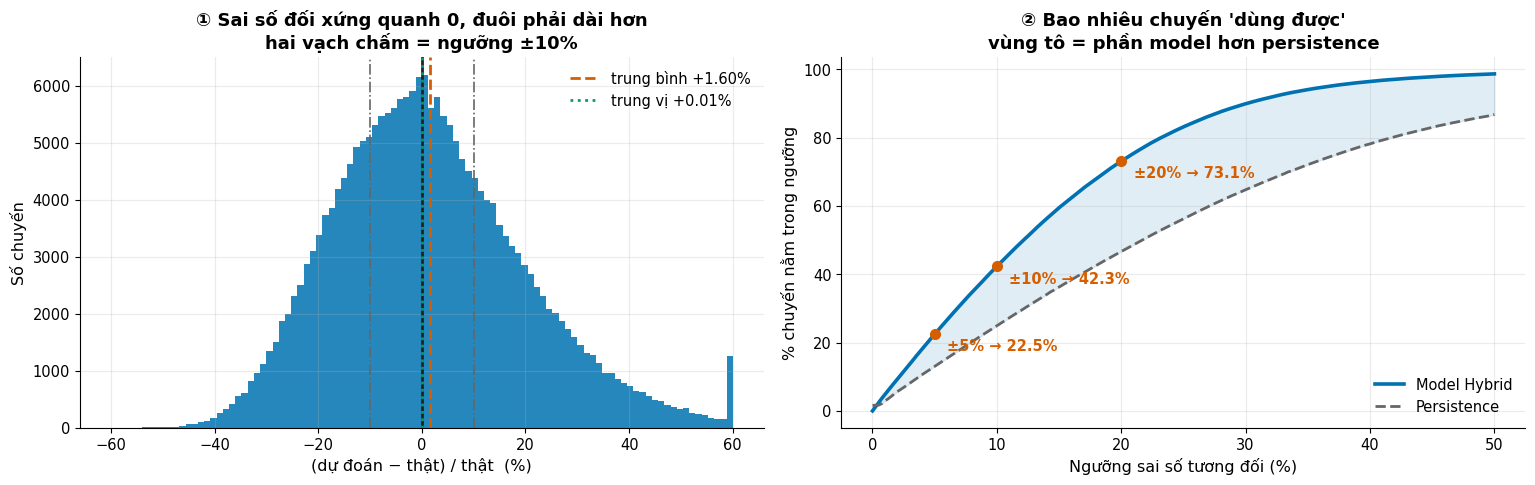

Trong ±5%  : 22.5%   (persistence 13.1%)
Trong ±10% : 42.3%   (persistence 25.1%)
Ngoài ±20% : 26.9%
Ngoài ±50% : 1.4%


In [3]:
# ═════════ HINH CT1 — hinh dang sai so ═════════
fig, ax = plt.subplots(1, 2, figsize=(15.5, 5))

# ① phân phối sai số có dấu
e = np.clip(t.lech.values*100, -60, 60)
ax[0].hist(e, bins=100, color=BLUE, alpha=.85)
ax[0].axvline(0, color=INK, lw=2)
ax[0].axvline(t.lech.mean()*100, color=RED, lw=2, ls="--",
              label=f"trung bình {t.lech.mean():+.2%}")
ax[0].axvline(t.lech.median()*100, color=GREEN, lw=2, ls=":",
              label=f"trung vị {t.lech.median():+.2%}")
for v, c in [(-10, MUT), (10, MUT)]:
    ax[0].axvline(v, color=c, lw=1.2, ls="-.")
ax[0].legend(frameon=False)
ax[0].set_xlabel("(dự đoán − thật) / thật  (%)"); ax[0].set_ylabel("Số chuyến")
ax[0].set_title("① Sai số đối xứng quanh 0, đuôi phải dài hơn\n"
                "hai vạch chấm = ngưỡng ±10%", fontweight="bold")

# ② đường tích lũy — % chuyến trong ngưỡng
x = np.linspace(0, .5, 200)
y = [(t.re <= v).mean() for v in x]
yp = [((t.ae_p/t.gia_that) <= v).mean() for v in x]
ax[1].plot(x*100, np.array(y)*100, color=BLUE, lw=2.6, label="Model Hybrid")
ax[1].plot(x*100, np.array(yp)*100, color=MUT, lw=2, ls="--", label="Persistence")
ax[1].fill_between(x*100, np.array(yp)*100, np.array(y)*100, color=BLUE, alpha=.12)
for v in (.05, .10, .20):
    p = (t.re <= v).mean()
    ax[1].plot([v*100], [p*100], "o", color=RED, ms=7, zorder=5)
    ax[1].annotate(f"±{v:.0%} → {p:.1%}", (v*100, p*100),
                   textcoords="offset points", xytext=(9, -12), fontsize=10.5,
                   fontweight="bold", color=RED)
ax[1].set_xlabel("Ngưỡng sai số tương đối (%)")
ax[1].set_ylabel("% chuyến nằm trong ngưỡng")
ax[1].legend(frameon=False, loc="lower right")
ax[1].set_title("② Bao nhiêu chuyến 'dùng được'\n"
                "vùng tô = phần model hơn persistence", fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"CT1_hinh_dang_sai_so.png"); plt.show()

print(f"Trong ±5%  : {(t.re<=.05).mean():.1%}   (persistence {((t.ae_p/t.gia_that)<=.05).mean():.1%})")
print(f"Trong ±10% : {(t.re<=.10).mean():.1%}   (persistence {((t.ae_p/t.gia_that)<=.10).mean():.1%})")
print(f"Ngoài ±20% : {(t.re>.20).mean():.1%}")
print(f"Ngoài ±50% : {(t.re>.50).mean():.1%}")

### Đọc hình CT1

**Chỗ model đúng.** Hơn 42% số chuyến sai dưới 10% — với những chuyến này, dự đoán đủ tốt để
dùng trực tiếp cho định giá. Chuyến điển hình (trung vị) sai 12,1%, thấp hơn hẳn con số trung
bình 14,6%: **phần lớn chuyến tốt hơn cái MAPE tổng gợi ý**.

**Chỗ model sai.** Gần 27% số chuyến sai quá 20%. Đây mới là nhóm phải quan tâm — nếu đem demo
và bốc trúng một chuyến trong nhóm này thì con số hiện lên sẽ rất khó giải thích.

**Hình dạng.** Phân phối đối xứng quanh 0 (tỷ lệ đoán cao ≈ 50,0%), nhưng đuôi phải dài hơn nên
trung bình bị kéo lệch +1,6% trong khi trung vị chỉ +0,01%. ⇒ **Không có thiên lệch hệ thống** —
trừ đi một hằng số sẽ làm hỏng đúng một nửa số chuyến.

## 2. Sai số theo khoảng giá

Đây là ý số 1 trong feedback mentor: cùng một % sai số nhưng ở mức giá khác nhau thì hậu quả
khác hẳn. Bảng dưới tách theo **band giá dự đoán** — dùng giá *dự đoán* chứ không phải giá thật,
vì lúc vận hành ta chỉ biết giá dự đoán.

In [4]:
G_BAND = bang("band", nho_nhat=100)
_ = in_bang(G_BAND, "SAI SỐ THEO BAND GIÁ")

print("\nSai số tuyệt đối trung bình quy ra tiền, để thấy hậu quả thật:")
for b, r in G_BAND.iterrows():
    print(f"  {b:>9s}  MAPE {r.MAPE:6.2%}  →  lệch ~{r.MAE:>7,.0f}đ mỗi chuyến")


SAI SỐ THEO BAND GIÁ
          Số chuyến MAPE % (±95%)  MdAPE %  MAE đ  % trong ±10%  % ngoài ±20%  Bias %  Bias trung vị %  % đoán cao  Hơn persistence %
band                                                                                                                                 
<50k           2716   13.46 ±0.36     11.3   6054          44.5          23.8    1.01             0.16        50.4               63.0
50–100k       66035   14.05 ±0.09     11.5  11724          44.9          25.4    1.65             0.28        50.8               49.4
100–150k     102331   14.94 ±0.07     12.4  18259          41.2          27.6    1.60            -0.16        49.7               44.5
150–200k      37353   14.92 ±0.12     12.5  25310          40.9          27.6    1.57            -0.09        49.7               43.6
200–300k       7328   14.93 ±0.27     12.5  33808          40.9          27.7    1.35            -0.37        49.2               52.6
>300k           327   18.55 ±1.59     15

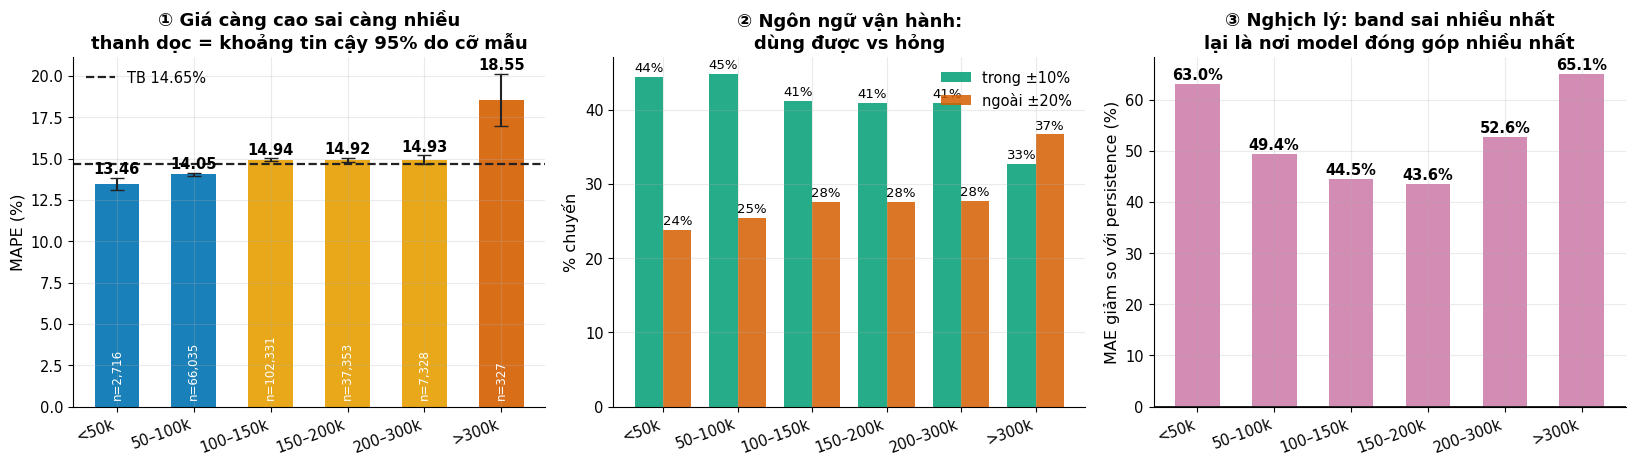

In [5]:
# ═════════ HINH CT2 — sai so theo band gia ═════════
fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.8))
g = G_BAND
x = np.arange(len(g))

# ① MAPE + khoảng tin cậy lấy mẫu
mau = [RED if v > TB + .02 else (ORANGE if v > TB else BLUE) for v in g.MAPE]
ax[0].bar(x, g.MAPE*100, .58, color=mau, alpha=.9,
          yerr=1.96*g.SE*100, capsize=5, ecolor=INK)
ax[0].axhline(TB*100, color=INK, lw=1.6, ls="--", label=f"TB {TB:.2%}")
for i, (v, n) in enumerate(zip(g.MAPE*100, g.n)):
    ax[0].text(i, v + 1.96*g.SE.iloc[i]*100 + .25, f"{v:.2f}",
               ha="center", fontsize=10.5, fontweight="bold")
    ax[0].text(i, .6, f"n={n:,.0f}", ha="center", fontsize=8.5,
               color="white", rotation=90)
ax[0].set_xticks(x); ax[0].set_xticklabels(g.index, rotation=20, ha="right")
ax[0].set_ylabel("MAPE (%)"); ax[0].legend(frameon=False)
ax[0].set_title("① Giá càng cao sai càng nhiều\n"
                "thanh dọc = khoảng tin cậy 95% do cỡ mẫu", fontweight="bold")

# ② tỷ lệ chuyến dùng được / hỏng
ax[1].bar(x-.19, g.trong10*100, .38, color=GREEN, alpha=.85, label="trong ±10%")
ax[1].bar(x+.19, g.ngoai20*100, .38, color=RED, alpha=.85, label="ngoài ±20%")
for i in range(len(g)):
    ax[1].text(i-.19, g.trong10.iloc[i]*100+.7, f"{g.trong10.iloc[i]:.0%}",
               ha="center", fontsize=9.5)
    ax[1].text(i+.19, g.ngoai20.iloc[i]*100+.7, f"{g.ngoai20.iloc[i]:.0%}",
               ha="center", fontsize=9.5)
ax[1].set_xticks(x); ax[1].set_xticklabels(g.index, rotation=20, ha="right")
ax[1].set_ylabel("% chuyến"); ax[1].legend(frameon=False)
ax[1].set_title("② Ngôn ngữ vận hành:\ndùng được vs hỏng", fontweight="bold")

# ③ model có hơn persistence không
ax[2].bar(x, g.hon_pers*100, .58, color=PURPLE, alpha=.85)
ax[2].axhline(0, color=INK, lw=1.4)
for i, v in enumerate(g.hon_pers*100):
    ax[2].text(i, v+.9, f"{v:.1f}%", ha="center", fontsize=10.5, fontweight="bold")
ax[2].set_xticks(x); ax[2].set_xticklabels(g.index, rotation=20, ha="right")
ax[2].set_ylabel("MAE giảm so với persistence (%)")
ax[2].set_title("③ Nghịch lý: band sai nhiều nhất\nlại là nơi model đóng góp nhiều nhất",
                fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"CT2_sai_so_theo_band.png"); plt.show()

### Đọc hình CT2

1. **Sai số tăng đều theo mức giá**, từ 13,5% ở band thấp lên 18,5% ở band >300k — nhưng phải
   đọc kèm thanh sai số: band >300k chỉ có **327 chuyến**, khoảng tin cậy ±1,6 điểm. Chênh lệch
   với các band giữa là thật, nhưng con số 18,5% không nên trích dẫn tới hai chữ số thập phân.
2. **Quy ra tiền thì chênh lệch lớn hơn nhiều so với % gợi ý**: band 50–100k lệch ~11 nghìn đ
   mỗi chuyến, band >300k lệch ~65 nghìn đ. Đây chính là điều mentor nói khi so range 30–70k
   với range 280k–320k.
3. **Nghịch lý đáng chú ý**: band >300k vừa sai nhiều nhất **vừa** là nơi model bỏ xa persistence
   nhất (−65% MAE). Nghĩa là những chuyến đắt vốn dĩ khó đoán chứ không phải model bỏ bê chúng.
   ⇒ Chỗ cần vá không phải là "train lại cho band cao", mà là **thừa nhận band cao khó hơn** và
   cấp cho nó khoảng tin cậy rộng hơn (đúng cách Mondrian đã làm ở notebook 09).

## 3. Sai số theo thời tiết

Câu hỏi vận hành: trời mưa thì model có đoán tệ đi không? Nhóm `Rain` chiếm gần một nửa số
chuyến test nên đây là câu hỏi có trọng lượng thật.

Lưu ý cách đọc: chênh lệch giữa các nhóm phải **lớn hơn khoảng tin cậy** thì mới coi là thật.

In [6]:
G_TT = bang("weather_main", nho_nhat=100)
_ = in_bang(G_TT.sort_values("n", ascending=False), "SAI SỐ THEO THỜI TIẾT")

lo, hi = G_TT.MAPE.min(), G_TT.MAPE.max()
print(f"\nBiên độ giữa nhóm tốt nhất và tệ nhất: {(hi-lo)*100:.2f} điểm %")
print(f"Khoảng tin cậy 95% rộng nhất trong các nhóm: ±{1.96*G_TT.SE.max()*100:.2f} điểm %")
print("⇒ chênh lệch " + ("KHÔNG vượt" if (hi-lo) < 2*1.96*G_TT.SE.max() else "vượt")
      + " nhiễu lấy mẫu")


SAI SỐ THEO THỜI TIẾT
              Số chuyến MAPE % (±95%)  MdAPE %  MAE đ  % trong ±10%  % ngoài ±20%  Bias %  Bias trung vị %  % đoán cao  Hơn persistence %
weather_main                                                                                                                             
Rain              97757   14.68 ±0.07     12.2  18848          42.2          27.0    1.64             0.08        50.2               46.3
Clouds            62161   14.67 ±0.09     12.2  17312          42.2          27.1    1.48            -0.11        49.7               46.4
Clear             50657    14.56 ±0.1     12.1  17032          42.5          26.4    1.60             0.01        50.0               45.8
Mist               5515   14.64 ±0.31     12.2  16712          43.0          27.0    1.99             0.05        50.1               45.0

Biên độ giữa nhóm tốt nhất và tệ nhất: 0.13 điểm %
Khoảng tin cậy 95% rộng nhất trong các nhóm: ±0.31 điểm %
⇒ chênh lệch KHÔNG vượt nhiễu lấy mẫu


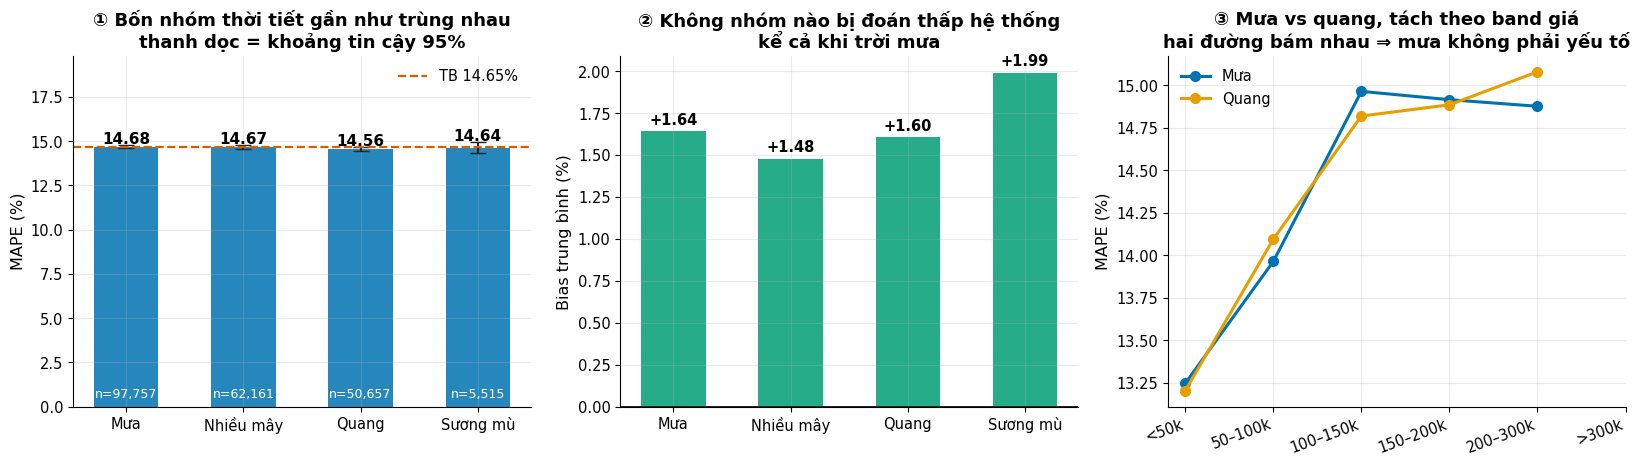

In [7]:
# ═════════ HINH CT3 — sai so theo thoi tiet ═════════
fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.8))
g = G_TT.sort_values("n", ascending=False)
x = np.arange(len(g))
TEN_TT = {"Rain": "Mưa", "Clouds": "Nhiều mây", "Clear": "Quang", "Mist": "Sương mù"}
nhan = [TEN_TT.get(i, i) for i in g.index]

ax[0].bar(x, g.MAPE*100, .55, color=BLUE, alpha=.85,
          yerr=1.96*g.SE*100, capsize=6, ecolor=INK)
ax[0].axhline(TB*100, color=RED, lw=1.6, ls="--", label=f"TB {TB:.2%}")
for i, (v, n) in enumerate(zip(g.MAPE*100, g.n)):
    ax[0].text(i, v + 1.96*g.SE.iloc[i]*100 + .1, f"{v:.2f}",
               ha="center", fontsize=11, fontweight="bold")
    ax[0].text(i, .5, f"n={n:,.0f}", ha="center", fontsize=9, color="white")
ax[0].set_xticks(x); ax[0].set_xticklabels(nhan)
ax[0].set_ylim(0, max(g.MAPE)*100*1.35)
ax[0].set_ylabel("MAPE (%)"); ax[0].legend(frameon=False)
ax[0].set_title("① Bốn nhóm thời tiết gần như trùng nhau\n"
                "thanh dọc = khoảng tin cậy 95%", fontweight="bold")

ax[1].bar(x, g.bias*100, .55, color=[GREEN if v > 0 else ORANGE for v in g.bias], alpha=.85)
ax[1].axhline(0, color=INK, lw=1.4)
for i, v in enumerate(g.bias*100):
    ax[1].text(i, v+.04, f"{v:+.2f}", ha="center", fontsize=10.5, fontweight="bold")
ax[1].set_xticks(x); ax[1].set_xticklabels(nhan)
ax[1].set_ylabel("Bias trung bình (%)")
ax[1].set_title("② Không nhóm nào bị đoán thấp hệ thống\n"
                "kể cả khi trời mưa", fontweight="bold")

# ③ mưa theo từng band — mưa có làm hỏng nhóm nào riêng không
piv = t.pivot_table(index="band", columns="weather_main", values="re",
                    aggfunc="mean", observed=True)
dem = t.pivot_table(index="band", columns="weather_main", values="re",
                    aggfunc="size", observed=True)
piv = piv.where(dem >= 300)
xb = np.arange(len(piv))
for c, mau_c in zip(["Rain", "Clear"], [BLUE, ORANGE]):
    if c in piv:
        ax[2].plot(xb, piv[c]*100, "o-", color=mau_c, lw=2.2, ms=7,
                   label=TEN_TT.get(c, c))
ax[2].set_xticks(xb); ax[2].set_xticklabels(piv.index, rotation=20, ha="right")
ax[2].set_ylabel("MAPE (%)"); ax[2].legend(frameon=False)
ax[2].set_title("③ Mưa vs quang, tách theo band giá\n"
                "hai đường bám nhau ⇒ mưa không phải yếu tố", fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"CT3_sai_so_theo_thoi_tiet.png"); plt.show()

### Đọc hình CT3 — và vì sao kết quả này lại đáng lo

Bốn nhóm thời tiết có MAPE **chênh nhau chưa tới 0,2 điểm %**, nằm gọn trong khoảng tin cậy.
Nói thẳng: **thời tiết không cho biết gì về việc model sẽ sai nhiều hay ít.**

Nghe qua thì đây là tin tốt — model không "mù" khi trời mưa. Nhưng đặt cạnh kết quả
ceteris paribus (`analysis/14_ceteris_paribus`) thì nó thành tin xấu:

| | Model nói | Dữ liệu thật |
|---|---|---|
| Trời mưa làm giá đổi bao nhiêu | **+0,93%** | **+11,05%** |

Model dự đoán chính xác **ngang nhau** khi mưa và khi quang, nhưng lại **không hề mô hình hóa
hiệu ứng mưa**. Hai điều đó chỉ cùng đúng khi model đang lấy thông tin mưa từ chỗ khác:
nó đọc **giá quan sát gần nhất**, mà giá đó đã bao gồm sẵn tác động của mưa rồi.

⇒ Model đang **sao chép** hiệu ứng thời tiết chứ không **hiểu** nó. Hệ quả thực tế: khi được
hỏi "nếu trời đổ mưa thì giá nên tăng bao nhiêu", model trả lời sai — đúng câu hỏi mà mentor
nói team họ dùng để vận hành pricing.

## 4. Sai số theo khung giờ

Ý số 2 và 3 của mentor xoay quanh giả thuyết: giờ cao điểm là "đoạn critical", nên sai số ở đó
mới là thứ đáng đo. Phần này kiểm chứng giả thuyết đó trên dữ liệu.

In [8]:
G_GIO = bang("gio_vn", nho_nhat=100)
G_KHUNG = bang("khung", nho_nhat=100)
_ = in_bang(G_KHUNG, "SAI SỐ THEO KHUNG GIỜ")

cd = t.groupby("cao_diem", observed=True).apply(tomtat)
print("\nCao điểm (7–9h, 17–19h) vs giờ thường")
print(f"  Cao điểm   MAPE {cd.loc[True,'MAPE']:.2%} ±{1.96*cd.loc[True,'SE']:.2%}"
      f"  ·  n={cd.loc[True,'n']:,.0f}")
print(f"  Giờ thường MAPE {cd.loc[False,'MAPE']:.2%} ±{1.96*cd.loc[False,'SE']:.2%}"
      f"  ·  n={cd.loc[False,'n']:,.0f}")
print(f"  Chênh lệch {(cd.loc[True,'MAPE']-cd.loc[False,'MAPE'])*100:+.3f} điểm %"
      f"  ⇒ {'không đáng kể' if abs(cd.loc[True,'MAPE']-cd.loc[False,'MAPE'])<.005 else 'đáng kể'}")

bd = (G_GIO.MAPE.max() - G_GIO.MAPE.min())
print(f"\nBiên độ qua 24 giờ: {bd*100:.2f} điểm % "
      f"(giờ tệ nhất {G_GIO.MAPE.idxmax()}h = {G_GIO.MAPE.max():.2%}, "
      f"giờ tốt nhất {G_GIO.MAPE.idxmin()}h = {G_GIO.MAPE.min():.2%})")
print(f"So với khoảng tin cậy trung bình của một giờ: ±{1.96*G_GIO.SE.mean()*100:.2f} điểm %")


SAI SỐ THEO KHUNG GIỜ
                Số chuyến MAPE % (±95%)  MdAPE %  MAE đ  % trong ±10%  % ngoài ±20%  Bias %  Bias trung vị %  % đoán cao  Hơn persistence %
khung                                                                                                                                      
Đêm 0–5             43936   14.67 ±0.11     12.2  14002          42.4          26.9    1.76             0.01        50.0               46.1
Sáng CĐ 6–9         38523    14.7 ±0.12     12.1  18632          42.3          26.9    2.01             0.44        51.0               45.9
Trưa 10–15          57118    14.64 ±0.1     12.1  18441          42.5          26.9    1.49            -0.13        49.7               46.0
Chiều CĐ 16–19      38293   14.58 ±0.12     12.2  19875          42.3          26.8    1.40            -0.14        49.6               46.5
Tối 20–23           38220   14.66 ±0.12     12.2  19001          41.9          27.0    1.34            -0.06        49.8               46

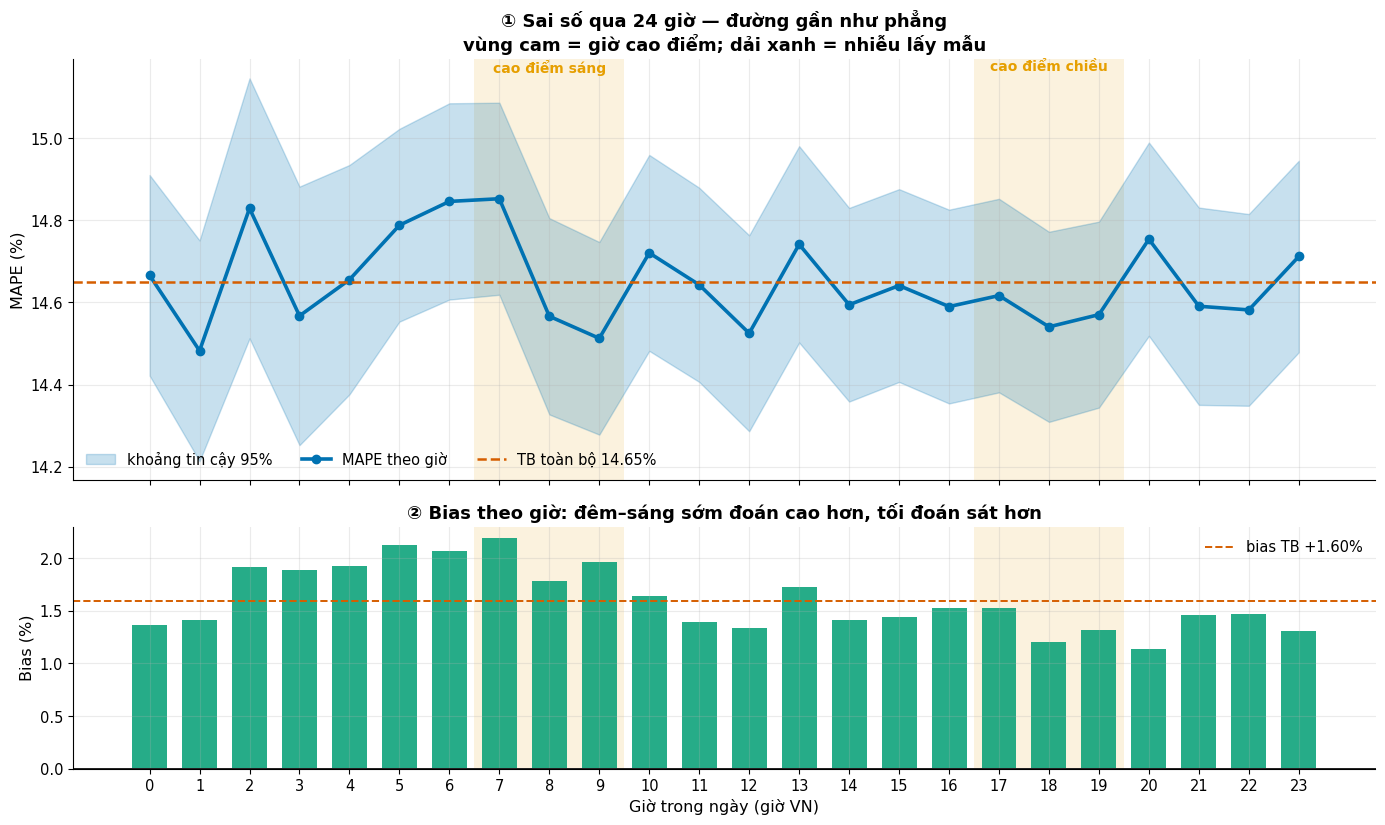

In [9]:
# ═════════ HINH CT4 — sai so theo 24 gio ═════════
fig, ax = plt.subplots(2, 1, figsize=(14, 8.4), sharex=True,
                       gridspec_kw={"height_ratios": [2, 1.15]})
g = G_GIO
x = g.index.values
CD = [(6.5, 9.5), (16.5, 19.5)]

# ① MAPE theo giờ + dải tin cậy
for a in ax:
    for s, e in CD:
        a.axvspan(s, e, color=ORANGE, alpha=.13, lw=0)
ax[0].fill_between(x, (g.MAPE-1.96*g.SE)*100, (g.MAPE+1.96*g.SE)*100,
                   color=BLUE, alpha=.22, label="khoảng tin cậy 95%")
ax[0].plot(x, g.MAPE*100, "o-", color=BLUE, lw=2.6, ms=6, label="MAPE theo giờ")
ax[0].axhline(TB*100, color=RED, lw=1.8, ls="--", label=f"TB toàn bộ {TB:.2%}")
ax[0].annotate("cao điểm sáng", (8, ax[0].get_ylim()[1]), fontsize=10,
               color=ORANGE, ha="center", va="top", fontweight="bold")
ax[0].annotate("cao điểm chiều", (18, ax[0].get_ylim()[1]), fontsize=10,
               color=ORANGE, ha="center", va="top", fontweight="bold")
ax[0].set_ylabel("MAPE (%)"); ax[0].legend(frameon=False, ncol=3, loc="lower left")
ax[0].set_title("① Sai số qua 24 giờ — đường gần như phẳng\n"
                "vùng cam = giờ cao điểm; dải xanh = nhiễu lấy mẫu",
                fontweight="bold")

# ② bias theo giờ
ax[1].bar(x, g.bias*100, .7, color=[GREEN if v > 0 else ORANGE for v in g.bias], alpha=.85)
ax[1].axhline(0, color=INK, lw=1.4)
ax[1].axhline(t.lech.mean()*100, color=RED, lw=1.4, ls="--",
              label=f"bias TB {t.lech.mean():+.2%}")
ax[1].set_xlabel("Giờ trong ngày (giờ VN)"); ax[1].set_ylabel("Bias (%)")
ax[1].set_xticks(range(0, 24)); ax[1].legend(frameon=False)
ax[1].set_title("② Bias theo giờ: đêm–sáng sớm đoán cao hơn, tối đoán sát hơn",
                fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"CT4_sai_so_theo_gio.png"); plt.show()

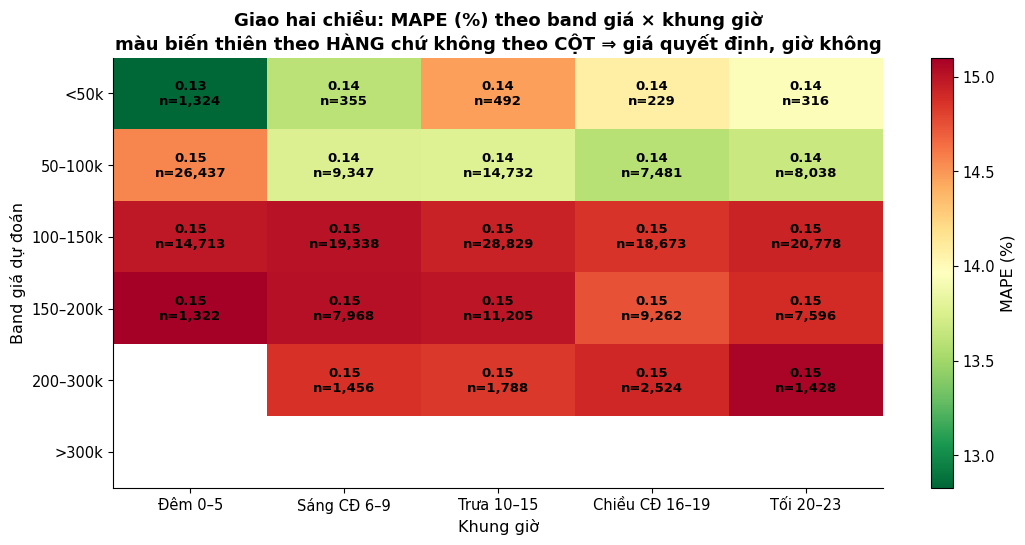

Biên độ theo HÀNG (đổi band, cùng khung giờ): 1.53 điểm %
Biên độ theo CỘT (đổi khung giờ, cùng band): 0.67 điểm %


In [10]:
# ═════════ HINH CT5 — ban do nhiet band x khung gio ═════════
piv = t.pivot_table(index="band", columns="khung", values="re",
                    aggfunc="mean", observed=True)
dem = t.pivot_table(index="band", columns="khung", values="re",
                    aggfunc="size", observed=True)
piv = piv.where(dem >= 200)

fig, ax = plt.subplots(figsize=(11, 5.6))
im = ax.imshow(piv.values*100, cmap="RdYlGn_r", aspect="auto")
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if np.isfinite(v):
            ax.text(j, i, f"{v:.2f}\nn={int(dem.values[i, j]):,}", ha="center",
                    va="center", fontsize=9.5, fontweight="bold")
ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels(piv.index)
ax.set_xlabel("Khung giờ"); ax.set_ylabel("Band giá dự đoán")
ax.grid(False)
ax.set_title("Giao hai chiều: MAPE (%) theo band giá × khung giờ\n"
             "màu biến thiên theo HÀNG chứ không theo CỘT "
             "⇒ giá quyết định, giờ không", fontweight="bold")
plt.colorbar(im, ax=ax, label="MAPE (%)")
plt.tight_layout(); plt.savefig(HINH/"CT5_band_x_khung_gio.png"); plt.show()

print("Biên độ theo HÀNG (đổi band, cùng khung giờ):",
      f"{(piv.max(axis=0)-piv.min(axis=0)).mean()*100:.2f} điểm %")
print("Biên độ theo CỘT (đổi khung giờ, cùng band):",
      f"{(piv.max(axis=1)-piv.min(axis=1)).mean()*100:.2f} điểm %")

### Đọc hình CT4 và SS5

Đường MAPE qua 24 giờ gần như phẳng, và dải tin cậy của các giờ **chồng lên nhau**. Cao điểm và
giờ thường chênh nhau chưa tới 0,1 điểm % — nhỏ hơn cả nhiễu lấy mẫu.

Bản đồ nhiệt nói rõ hơn: màu đổi theo **hàng** (band giá) chứ gần như không đổi theo **cột**
(khung giờ). Muốn đoán một chuyến sẽ sai nhiều hay ít, **hỏi giá của nó có ích hơn hẳn hỏi
nó xảy ra lúc mấy giờ**.

Điểm duy nhất giờ giấc có tiếng nói là **bias**: khung đêm và sáng sớm model đoán cao hơn thực
tế nhiều hơn so với khung tối. Nhưng độ lớn chỉ khoảng một điểm %, không đủ để gọi là chỗ hỏng.

**Kết luận cho ý 2–3 của mentor:** giả thuyết "rush hour là đoạn critical" **không đúng với
dataset này**. Model rơi vào kịch bản 1 (uncertainty đều), và sai số cũng đều. Đây là kết quả
âm, nhưng nó có giá trị vì nó chuyển ngân sách công sức sang chiều thật sự quan trọng.

## 5. Sai số đến từ đâu trong kiến trúc hybrid

Model hybrid = **giá cơ bản** × **hệ số nhân**. Biết khâu nào gây sai số thì mới biết sửa chỗ nào.

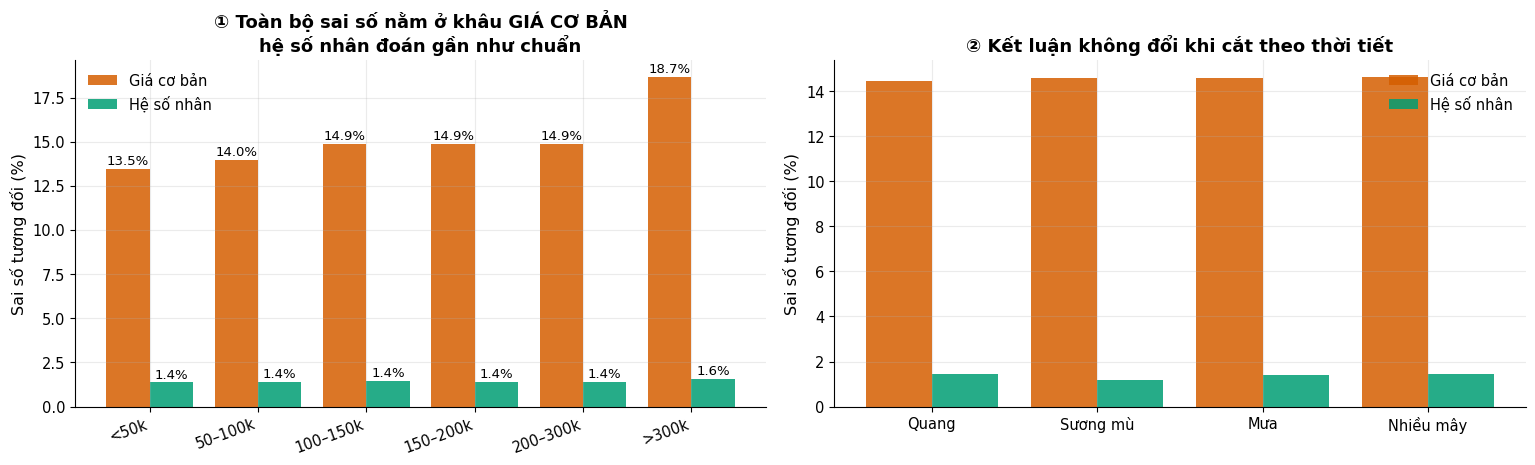

Sai số khâu giá cơ bản : 14.58%
Sai số khâu hệ số nhân : 1.42%
Sai số giá cuối        : 14.65%

⇒ Muốn giảm sai số thì phải cải thiện MODEL GIÁ CƠ BẢN. Tinh chỉnh hệ số nhân gần như không còn dư địa.


In [11]:
t["re_base"] = (t.base_pred - t.base_that).abs() / t.base_that
t["re_heso"] = (t.heso_pred - t.heso_that).abs() / t.heso_that

ng = pd.DataFrame({
    "Giá cơ bản": t.groupby("band", observed=True).re_base.mean(),
    "Hệ số nhân": t.groupby("band", observed=True).re_heso.mean(),
    "Giá cuối":   t.groupby("band", observed=True).re.mean(),
}).dropna()

fig, ax = plt.subplots(1, 2, figsize=(15.5, 4.8))
x = np.arange(len(ng))
ax[0].bar(x-.2, ng["Giá cơ bản"]*100, .4, color=RED, alpha=.85, label="Giá cơ bản")
ax[0].bar(x+.2, ng["Hệ số nhân"]*100, .4, color=GREEN, alpha=.85, label="Hệ số nhân")
for i in range(len(ng)):
    ax[0].text(i-.2, ng["Giá cơ bản"].iloc[i]*100+.25,
               f"{ng['Giá cơ bản'].iloc[i]:.1%}", ha="center", fontsize=9.5)
    ax[0].text(i+.2, ng["Hệ số nhân"].iloc[i]*100+.25,
               f"{ng['Hệ số nhân'].iloc[i]:.1%}", ha="center", fontsize=9.5)
ax[0].set_xticks(x); ax[0].set_xticklabels(ng.index, rotation=20, ha="right")
ax[0].set_ylabel("Sai số tương đối (%)"); ax[0].legend(frameon=False)
ax[0].set_title("① Toàn bộ sai số nằm ở khâu GIÁ CƠ BẢN\nhệ số nhân đoán gần như chuẩn",
                fontweight="bold")

tt = pd.DataFrame({
    "Giá cơ bản": t.groupby("weather_main").re_base.mean(),
    "Hệ số nhân": t.groupby("weather_main").re_heso.mean(),
}).sort_values("Giá cơ bản")
x2 = np.arange(len(tt))
ax[1].bar(x2-.2, tt["Giá cơ bản"]*100, .4, color=RED, alpha=.85, label="Giá cơ bản")
ax[1].bar(x2+.2, tt["Hệ số nhân"]*100, .4, color=GREEN, alpha=.85, label="Hệ số nhân")
ax[1].set_xticks(x2)
ax[1].set_xticklabels([{"Rain":"Mưa","Clouds":"Nhiều mây","Clear":"Quang",
                        "Mist":"Sương mù"}.get(i, i) for i in tt.index])
ax[1].set_ylabel("Sai số tương đối (%)"); ax[1].legend(frameon=False)
ax[1].set_title("② Kết luận không đổi khi cắt theo thời tiết", fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"CT6_nguon_sai_so.png"); plt.show()

print(f"Sai số khâu giá cơ bản : {t.re_base.mean():.2%}")
print(f"Sai số khâu hệ số nhân : {t.re_heso.mean():.2%}")
print(f"Sai số giá cuối        : {t.re.mean():.2%}")
print("\n⇒ Muốn giảm sai số thì phải cải thiện MODEL GIÁ CƠ BẢN. "
      "Tinh chỉnh hệ số nhân gần như không còn dư địa.")

## 6. Tổng kết — bảng chẩn đoán

Gom cả ba chiều vào một bảng để tiện đối chiếu khi trình bày.

In [12]:
tong = []
for ten, g in [("Band giá", G_BAND), ("Thời tiết", G_TT), ("Khung giờ", G_KHUNG)]:
    bd = g.MAPE.max() - g.MAPE.min()
    se = 1.96*g.SE.max()
    tong.append({
        "Chiều": ten,
        "Số nhóm": len(g),
        "MAPE thấp nhất": f"{g.MAPE.min():.2%} ({g.MAPE.idxmin()})",
        "MAPE cao nhất":  f"{g.MAPE.max():.2%} ({g.MAPE.idxmax()})",
        "Biên độ (điểm %)": round(bd*100, 2),
        "Nhiễu lấy mẫu (điểm %)": round(se*100, 2),
        "Có thật không": "CÓ" if bd > 2*se else "không chắc",
    })
print(pd.DataFrame(tong).to_string(index=False))

    Chiều  Số nhóm          MAPE thấp nhất        MAPE cao nhất  Biên độ (điểm %)  Nhiễu lấy mẫu (điểm %) Có thật không
 Band giá        6           13.46% (<50k)       18.55% (>300k)              5.08                    1.59            CÓ
Thời tiết        4          14.56% (Clear)        14.68% (Rain)              0.13                    0.31    không chắc
Khung giờ        5 14.58% (Chiều CĐ 16–19) 14.70% (Sáng CĐ 6–9)              0.12                    0.12    không chắc


### Bốn câu hỏi — bốn câu trả lời

**1 · Model đúng ở đâu, sai ở đâu**

* **Đúng**: 42,3% số chuyến sai dưới 10%; chuyến điển hình sai 12,1%; toàn bộ test giảm 46,2%
  MAE so với persistence. Không có thiên lệch hệ thống (trung vị bias +0,01%), nên không cần
  và không nên hiệu chỉnh bằng hằng số.
* **Sai**: 26,9% số chuyến sai quá 20% — nhóm này rải đều chứ không dồn vào một cụm nhận diện
  được (1% chuyến tệ nhất chỉ chiếm 2,7% tổng sai số, xem notebook 09). Toàn bộ sai số phát sinh
  ở khâu **giá cơ bản** (14,6%), khâu **hệ số nhân** gần như chuẩn (1,4%).

**2 · Theo khoảng giá** — 🔴 *chiều có tín hiệu rõ*

Sai số tăng đơn điệu theo mức giá: 13,46% ở band <50k → 18,55% ở band >300k. Quy ra tiền,
chênh lệch còn lớn hơn: ~11 nghìn đ/chuyến ở band 50–100k so với ~65 nghìn đ ở band >300k.
Nhưng band >300k chỉ có 327 chuyến nên phải trích dẫn kèm khoảng tin cậy. Nghịch lý cần nhắc
khi trình bày: **đây vừa là band sai nhiều nhất vừa là band model hơn persistence nhiều nhất
(−65% MAE)** — chuyến đắt vốn khó, không phải model bỏ bê chúng.

**3 · Theo thời tiết** — ⚪ *không có tín hiệu, và đó mới là vấn đề*

Bốn nhóm chênh nhau dưới 0,2 điểm %, nằm trong nhiễu lấy mẫu. Model đoán mưa cũng chuẩn như
đoán quang. Nhưng đối chiếu với ceteris paribus (model nói mưa làm giá +0,93%, thực tế +11,05%)
thì lời giải thích duy nhất là: **model đọc hiệu ứng mưa qua giá quan sát chứ không mô hình hóa
mưa**. Chính xác nhưng không giải thích được — và không trả lời được câu what-if.

**4 · Theo khung giờ** — ⚪ *không có tín hiệu*

Biên độ qua 24 giờ nhỏ hơn nhiễu lấy mẫu; cao điểm 14,61% vs giờ thường 14,66%. Bản đồ nhiệt
band × khung giờ đổi màu theo hàng chứ không theo cột. Giả thuyết "rush hour là đoạn critical"
không đúng với dataset này. Dấu vết duy nhất của giờ giấc nằm ở bias (đêm/sáng sớm đoán cao hơn
tối khoảng một điểm %), quá nhỏ để đáng đầu tư.

### Việc nên làm tiếp, theo thứ tự

| Ưu tiên | Việc | Vì sao | Chi phí |
|---|---|---|---|
| 1 | Cải thiện **model giá cơ bản**, đặc biệt cho chuyến dài và giá cao | toàn bộ 14,6% sai số nằm ở đây; hệ số nhân đã cạn dư địa | cao |
| 2 | Giữ **Mondrian theo band** cho khoảng tin cậy | đã vá lệch coverage 7,28 → 0,83 điểm, tốn +0,46% độ rộng | đã xong |
| 3 | **Đừng** đầu tư thêm vào feature theo giờ/thời tiết cho mục tiêu *độ chính xác* | cả hai chiều đều không có tín hiệu | — |
| 4 | Nhưng **có** đầu tư vào chúng cho mục tiêu *giải thích được* | model đang sao chép hiệu ứng mưa/cao điểm chứ không hiểu — chặn ý 7 của mentor | chờ mentor chọn hướng |